# Proyecto Final - Curso Data Science BIT 202604
## Alumna: Abril Gabriela de los Angeles Sanchez Perez
## 31 de Julio 20256

## Predicción de Rating Promedio en Goodreads (Plataforma de Lectura)

### Objetivo: Observar si es posible predecir el rating promedio de un libro a partir de las características que componen en Goodreads: Paginas, cantidad de reseñas, idioma y editoral

In [1]:
# Cargue de los recursos y librerías necesarias para poder ejecutar el código. 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Y cargue del data set

df = pd.read_csv("Goodreads - PY Final.csv", on_bad_lines='skip') # Esto debido a que el excel tiene líneas con información corrupta que no van a correr en el codigo
df.head()

# Limpiar espacios en blanco de los nombres de columnas
df.columns = df.columns.str.strip()
df.columns

Index(['bookID', 'title', 'authors', 'average_rating', 'isbn', 'isbn13',
       'language_code', 'num_pages', 'ratings_count', 'text_reviews_count',
       'publication_date', 'publisher'],
      dtype='object')

In [2]:
# Análisis de forma e información del tipo de datos por columna

df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11123 entries, 0 to 11122
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   bookID              11123 non-null  int64  
 1   title               11123 non-null  object 
 2   authors             11123 non-null  object 
 3   average_rating      11123 non-null  float64
 4   isbn                11123 non-null  object 
 5   isbn13              11123 non-null  int64  
 6   language_code       11123 non-null  object 
 7   num_pages           11123 non-null  int64  
 8   ratings_count       11123 non-null  int64  
 9   text_reviews_count  11123 non-null  int64  
 10  publication_date    11123 non-null  object 
 11  publisher           11123 non-null  object 
dtypes: float64(1), int64(5), object(6)
memory usage: 1.0+ MB


In [3]:
# Análisis de valores nulos y de estadísticas que se pueden sacar del data set.
df.isnull().sum()
df.describe()

,bookID,average_rating,isbn13,num_pages,ratings_count,text_reviews_count
count,11123.000000,11123.000000,1.112300e+04,11123.000000,1.112300e+04,11123.000000
mean,21310.856963,3.934075,9.759880e+12,336.405556,1.794285e+04,542.048099
std,13094.727252,0.350485,4.429758e+11,241.152626,1.124992e+05,2576.619589
min,1.000000,0.000000,8.987060e+09,0.000000,0.000000e+00,0.000000
25%,10277.500000,3.770000,9.780345e+12,192.000000,1.040000e+02,9.000000
50%,20287.000000,3.960000,9.780582e+12,299.000000,7.450000e+02,47.000000
75%,32104.500000,4.140000,9.780872e+12,416.000000,5.000500e+03,238.000000
max,45641.000000,5.000000,9.790008e+12,6576.000000,4.597666e+06,94265.000000


In [4]:
# Observación Importante: 
""""
No es normal que en las páginas exista algún libro de 0 páginas, es imposible
es por esto que pueden haber datos nulos que las funciones de is.null no haya reconocido
por alguna condicion en el valor, por eso se hace la siguiente relación
"""

# Libros con rating 0
print("Libros con average_rating = 0:", (df["average_rating"] == 0).sum())

# Libros con páginas en 0
print("Libros con num_pages = 0:", (df["num_pages"] == 0).sum())

# Para saber si se trata de casos comunes en ambas columnas o totalmente aislados
df[(df["average_rating"] == 0) | (df["num_pages"] == 0)].head(10)


Libros con average_rating = 0: 25
Libros con num_pages = 0: 76


,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
265,799,Out to Eat London 2002 (Lonely Planet Out to Eat),Lonely Planet/Mark Honan,0.00,1740592050,9781740592055,eng,295,0,0,9/1/2001,Lonely Planet
306,955,The 5 Love Languages / The 5 Love Languages Jo...,Gary Chapman,4.70,0802415318,9780802415318,eng,0,22,4,1/1/2005,Moody Publishers
375,1302,Juiced Official Strategy Guide,Doug Walsh,0.00,0744005612,9780744005615,eng,112,0,0,6/1/2005,BradyGames
853,2835,The Tragedy of Pudd'nhead Wilson,Mark Twain/Michael Prichard,3.79,140015068X,9781400150687,eng,0,3,0,1/1/2003,Tantor Media
987,3351,Open City 6: The Only Woman He Ever Left,Open City Magazine/James Purdy/Daniel Pinchbec...,0.00,189044717X,9781890447175,eng,200,0,0,10/13/2000,Grove Press Open City Books
1061,3593,Murder by Moonlight & Other Mysteries (New Adv...,NOT A BOOK,4.00,0743564677,9780743564670,eng,0,7,2,10/3/2006,Simon Schuster Audio
1064,3599,The Unfortunate Tobacconist & Other Mysteries ...,NOT A BOOK,3.50,074353395X,9780743533959,eng,0,12,1,10/1/2003,Simon & Schuster Audio
1230,4249,The Da Vinci Code (Robert Langdon #2),Dan Brown/Paul Michael,3.84,0739339788,9780739339787,eng,0,91,16,3/28/2006,Random House Audio
1558,5362,The Summons / The Brethren,John Grisham/Michael Beck/Frank Muller,3.99,0739342770,9780739342770,eng,0,241,9,10/10/2006,Random House Audio
1842,6542,The Patricia Cornwell CD Audio Treasury: All T...,Patricia Cornwell/Kate Burton,4.16,0060791217,9780060791216,eng,0,202,1,7/26/2005,HarperAudio


In [5]:
# Comparar si los libros con average_rating en 0 tampoco cuentan con rating_count
df[df["average_rating"] == 0][["title", "average_rating", "ratings_count"]]

,title,average_rating,ratings_count
265,Out to Eat London 2002 (Lonely Planet Out to Eat),0.0,0
375,Juiced Official Strategy Guide,0.0,0
987,Open City 6: The Only Woman He Ever Left,0.0,0
2532,How To Meditate: An Anthology Of Talks On Medi...,0.0,0
2533,Insights: Talks On The Nature Of Existence,0.0,0
2758,Venac sonetnih venaca; Puževa srma,0.0,0
3492,Brodie's notes on Aldous Huxley's brave new world,0.0,0
4241,American Film Guide,0.0,0
4677,The Man and the Author: John Milton: Twentieth...,0.0,0
5323,Canopy: A Work for Voice and Light in Harvard ...,0.0,0


# *Pequeña explicación del proceso y paso a seguir:* 

Existen al menos 3 variables que me podrían dañar considerablemente el modelo a entrenar porque, en esencia, no son un libro (Literalmente hay una categoría que lo explica)

1. Casos como los publisher llamados: BradyGames o HarperAudio indican que se pueden tratar de audiolibros 
2. En la columna de authors hay unos llamados NOT A BOOK
3. Al no contar con ningun rating_count se convierte en un dato inservible ¿Por qué? simplemente porque nadie se tomó el tiempo de calificarlo y el modelo lo tomaría como un patrón que en realidad ni siquiera es útil

Antes de continuar con cualquier otro paso es necesario hacer una limpieza adicional al dataset con los siguientes pasos:

1. Eliminar todo lo que diga NOT A BOOK, ese dato no me sirve
2. Los que tengan tanto rating_count como average_rating en 0 también se van

In [6]:
# Limpieza de los datos basura

df = df[df["authors"] != "NOT A BOOK"]
df = df[(df["ratings_count"] != 0)]

print("Verificacion de la limpieza tomando en cuenta average_rating",(df["average_rating"] == 0).sum())
print("¿Como quedó el dataset?", df.shape)

Verificacion de la limpieza tomando en cuenta average_rating 0
¿Como quedó el dataset? (11039, 12)


In [7]:
# Verificar si los datos de num_pages 0 (O sea los audiolibros), es un dato inútil para el modelo
print("Libros con num_pages = 0:", (df["num_pages"] == 0).sum())
df[df["num_pages"] == 0][["title", "publisher", "average_rating"]].head(10)

Libros con num_pages = 0: 73


,title,publisher,average_rating
306,The 5 Love Languages / The 5 Love Languages Jo...,Moody Publishers,4.70
853,The Tragedy of Pudd'nhead Wilson,Tantor Media,3.79
1230,The Da Vinci Code (Robert Langdon #2),Random House Audio,3.84
1558,The Summons / The Brethren,Random House Audio,3.99
1842,The Patricia Cornwell CD Audio Treasury: All T...,HarperAudio,4.16
1933,Like Water for Chocolate,Random House Audio,3.95
2105,A Study Guide to Gabriel Garcia Marquez' One H...,Warner Adult,4.11
2129,The Michael Crichton Collection: Airframe / Th...,Random House Audio,4.16
2151,Gulliver's Travels,Tantor Media,3.57
2440,Return to the Planet of the Apes #2: Escape fr...,Ballantine Books,3.00


# Explicación

Al no ser, si quiera, el 1% de los datos en el dataset es mejor no dejar estos datos ¿Porque? Al igual que los datos de las reviews que estaban en 0, este tipo de datos solo hace un estorbo computacional y el modelo podría malinterpretar y asumir que este es un valor normal. 

Es por esto que es necesario eliminarlos del dataset.

In [8]:
# Eliminar audiolibros y otros formatos sin número de páginas real
df = df[df["num_pages"] != 0]

print("¿Cómo quedó el dataset final?", df.shape)
df.describe()

¿Cómo quedó el dataset final? (10966, 12)


,bookID,average_rating,isbn13,num_pages,ratings_count,text_reviews_count
count,10966.000000,10966.000000,1.096600e+04,10966.000000,1.096600e+04,10966.000000
mean,21296.466533,3.943137,9.759574e+12,339.130038,1.819711e+04,549.706456
std,13105.169642,0.294201,4.461284e+11,240.182756,1.132814e+05,2594.195923
min,1.000000,1.000000,8.987060e+09,1.000000,1.000000e+00,0.000000
25%,10235.750000,3.780000,9.780345e+12,197.000000,1.132500e+02,10.000000
50%,20237.500000,3.960000,9.780571e+12,302.000000,7.820000e+02,48.000000
75%,32104.750000,4.140000,9.780872e+12,416.000000,5.141000e+03,244.750000
max,45641.000000,5.000000,9.790008e+12,6576.000000,4.597666e+06,94265.000000


# Conclusiones en el Análisis Exploratorio de Datos

El df.shape original contenía 11.123 entradas de datos de las cuales se pudieron corregir los siguientes errores:

1. En la primera importación de los datos, evité cargar los nombres de las columnas con un espacio que más adelante me traería problemas si no estaban bien escritas (Ejemplo existía la columna: "  num_pages")
2. Eliminé registros basura en las columnas de authors ("NOT A BOOK") y num_pages, que podrían haber confudido al modelo y no entregar datos confiables.
3. Eliminar cosas que no tenían relevancia y representaban un mayor esfuerzo computacional, en este caso lo que no tenía nada de rating

De 11.123 datos se logró resumir a 10.966 datos más utiles

# Graficas para entender la direccion que necesito tomar

Para poder responder directamente a que preguntas debo tomar para hacer la prediccion del rating promedio y mirarlas de forma más gráfica he decido hacer las siguientes tres:

1. Distribuición del Rating Promedio: Permite saber en donde estan concentrados los datos que el modelo necesita predecir (¿La mayoría son 2 estrellas o de pronto 5?)
2. Relacion entre el numero de paginas y el rating promedio: Permite detectar si el número de paginas influye en la calificación que le damos
3. Variable importante Idioma o Editorial: pueden representar un posible sesgo.

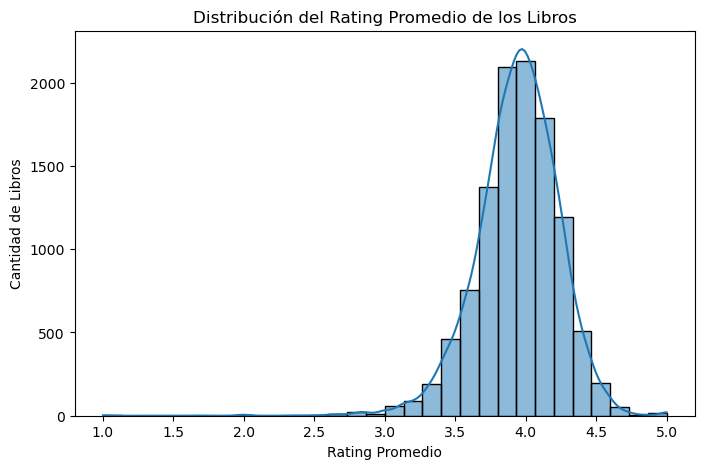

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df["average_rating"], bins=30, kde=True)
plt.title("Distribución del Rating Promedio de los Libros")
plt.xlabel("Rating Promedio")
plt.ylabel("Cantidad de Libros")
plt.show()

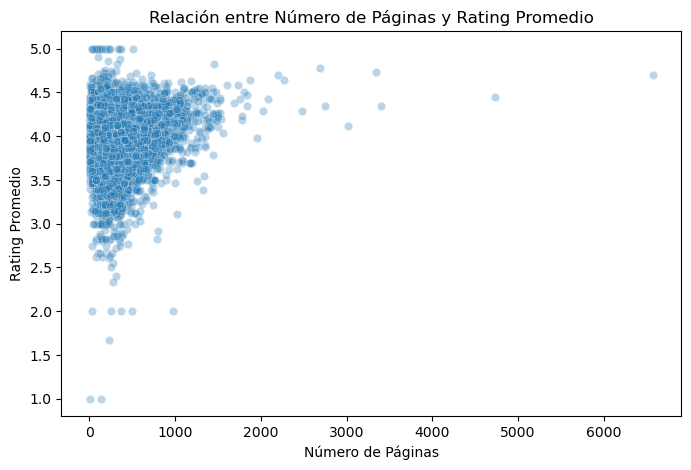

In [10]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="num_pages", y="average_rating", alpha=0.3)
plt.title("Relación entre Número de Páginas y Rating Promedio")
plt.xlabel("Número de Páginas")
plt.ylabel("Rating Promedio")
plt.show()

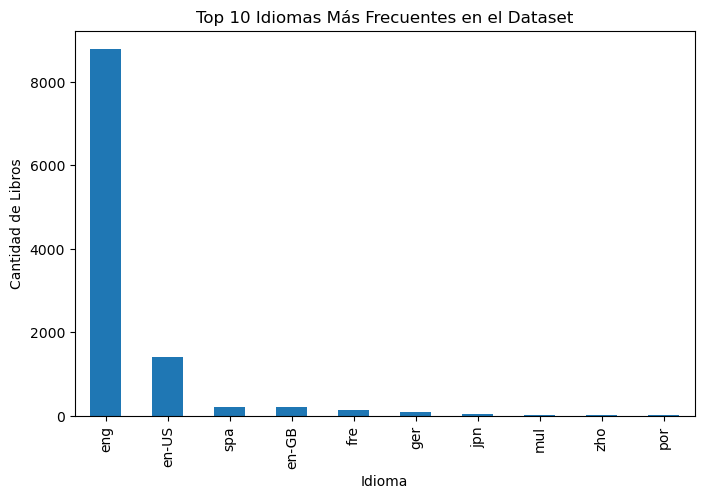

In [11]:
plt.figure(figsize=(8,5))
df["language_code"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Idiomas Más Frecuentes en el Dataset")
plt.xlabel("Idioma")
plt.ylabel("Cantidad de Libros")
plt.show()

# Variables Escogidas para el modelo

Predictoras (X): num_pages, publisher, language_code, authors, ratings_count, text_reviews_count, publicatio_year
Target (y): average_rating

In [12]:
# Preprocesamiento de los datos. 

# Como primer paso es necesario convertir las variables como año de publicación y fecha de publicación a un formato numérico para poder trabajar con ellas en el modelo de machine learning.

df["publication_year"] = pd.to_datetime(df["publication_date"], errors="coerce").dt.year
df[["publication_date", "publication_year"]].head()

df["publication_year"].isnull().sum()

np.int64(2)

In [13]:
# Como pueden ver, quedaron 2 valores nulos por lo que se puede realizar un .dropna ya que no son datos relevantes

df = df.dropna(subset=["publication_year"])
df["publication_year"] = df["publication_year"].astype(int)

print("Dataset final:", df.shape)

Dataset final: (10964, 13)


In [ ]:
# Siguiente paso mirar los tipos de datos que existen entre autores y editoriales (para saber si no son muchas y se puede transformar y agrupar o se deben eliminar)
print("Autores únicos:", df["authors"].nunique())
print("Editoriales únicas:", df["publisher"].nunique())

Autores únicos: 6543
Editoriales únicas: 2247


In [15]:
# Nos quedamos con las 30 editoriales y 30 autores más frecuentes; el resto se agrupa como "Other"
top_publishers = df["publisher"].value_counts().nlargest(30).index
df["publisher_grouped"] = df["publisher"].where(df["publisher"].isin(top_publishers), "Other")

top_authors = df["authors"].value_counts().nlargest(30).index
df["authors_grouped"] = df["authors"].where(df["authors"].isin(top_authors), "Other")

print("Categorías de publisher_grouped:", df["publisher_grouped"].nunique())
print("Categorías de authors_grouped:", df["authors_grouped"].nunique())
df["authors_grouped"].value_counts().head(10)

Categorías de publisher_grouped: 31
Categorías de authors_grouped: 31


authors_grouped
Other               10257
Stephen King           40
P.G. Wodehouse         40
Rumiko Takahashi       38
Orson Scott Card       35
Agatha Christie        33
Piers Anthony          30
Mercedes Lackey        29
Sandra Brown           29
Dick Francis           28
Name: count, dtype: int64

In [16]:
# Una vez que se han agrupado los autores y editoriales, se puede proceder a la codificación de las variables categóricas para el modelo de machine learning. 

features = ["num_pages", "publisher_grouped", "language_code", "authors_grouped",
            "ratings_count", "text_reviews_count", "publication_year"]

X = df[features]
y = df["average_rating"]

X.head()

,num_pages,publisher_grouped,language_code,authors_grouped,ratings_count,text_reviews_count,publication_year
0,652,Other,eng,Other,2095690,27591,2006
1,870,Other,eng,Other,2153167,29221,2004
2,352,Other,eng,Other,6333,244,2003
3,435,Other,eng,Other,2339585,36325,2004
4,2690,Other,eng,Other,41428,164,2004


In [17]:
# Division del dataset en conjunto de entrenamiento y prueba

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Tamaño de entrenamiento:", X_train.shape)
print("Tamaño de prueba:", X_test.shape)

Tamaño de entrenamiento: (8771, 7)
Tamaño de prueba: (2193, 7)


In [18]:
# Ahora si, One-Hot Encoding de las variables categóricas para poder trabajar con ellas en el modelo de machine learning.

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

cat_cols = ["publisher_grouped", "language_code", "authors_grouped"]
num_cols = ["num_pages", "ratings_count", "text_reviews_count", "publication_year"]

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", "passthrough", num_cols)
])

## Modelado de los datos

Empezaré con una baseline de Regresión Lineal, esto debido a que suele ser más simple e interpretable puede servir como un punto de comparacion (Por eso le digo baseline) contra los otros modelos que se usarán.

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

modelo_lineal = Pipeline([
    ("prep", preprocess),
    ("model", LinearRegression())
])

modelo_lineal.fit(X_train, y_train)
print("Modelo entrenado con éxito")

Modelo entrenado con éxito


In [20]:
# Es momento de evaluar las metricas mas usadas: MAE, RMSE y R2

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_lineal = modelo_lineal.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_lineal)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lineal))
r2 = r2_score(y_test, y_pred_lineal)

print(f"MAE:  {mae:.3f}") #¿Cuanto se puede equivocar este modelo?
print(f"RMSE: {rmse:.3f}") # Castido de MSE al cuadrado
print(f"R²:   {r2:.3f}") # Proporción de la varianza explicada

MAE:  0.220
RMSE: 0.296
R²:   0.024


## Conclusiones de la Regresión Lineal

1. MAE: Al rededor de 0.22 estrellas de rating de la predicción de un libro. Por ejemplo si el rating real es 4,0 el modelo se equivoca entre 3.78 y 4.22
2. RMSE: Indica que hay uno de los pocos casos donde se equivoca mas fuerte de lo normal.
3. R2: El modelo solo explica el 2,4% de la variacion de rating. Para la cantidad de datos, es super bajo.

Sin embargo tomando en cuenta la gráfica de los ratings, casi todos los rating están entre 3.5 y 4.5 por lo que el MAE no se equivoca tanto pero el R2 no puede explicar perfectamente porque hay libros con 3.9 estrellas y otro con 4.5

Para verificar si el margen de error persiste, es necesario seguir con los modelos

## Modelo 2: Random Forest Regressor.

Permite construir cientos de "arboles" de decision en este caso aca en el n_estimators serán 200 y cada una de estas ramas serán muestras con diferencias ligeras entre sí y permite capturar relacionales que no son lineales.

In [21]:
from sklearn.ensemble import RandomForestRegressor

modelo_rf = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
])

modelo_rf.fit(X_train, y_train)
print("Modelo Random Forest entrenado con éxito")

Modelo Random Forest entrenado con éxito


In [22]:
# Evaluación del modelo

y_pred_rf = modelo_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"MAE:  {mae_rf:.3f}")
print(f"RMSE: {rmse_rf:.3f}")
print(f"R²:   {r2_rf:.3f}")

MAE:  0.211
RMSE: 0.286
R²:   0.092


# Conclusiones del Random Forest Regresor

A diferencia de la baseline, el R2 se transformo en un 0.092 que esbajo en terminos generales pero representa una una mejora importante para esto. 

Esto debido a que el random forest captura relaciones no lineales e interacciones que hay entre las variables que quizas la regresión lineal (Al ser en linea recta) por ejemplo, quizás ratings_count alto combinado con ciertos idiomas predice mejor el rating que cualquiera de esas variables por separado.

Tanto el MAE como el RMSE mejora ya que estos rangos eran muy bajos en la regresión lineal.

# Modelo 3. Gradient Boosting

Construye arboles de forma secuencial y cada arbol que genera se enfoca en mejorar los errors que obtuvo anteriormente y por eso no se puede tomar de forma paralela ya que cada arbol depende del anterior.

In [23]:
from sklearn.ensemble import GradientBoostingRegressor

modelo_gb = Pipeline([
    ("prep", preprocess),
    ("model", GradientBoostingRegressor(random_state=42))
])

modelo_gb.fit(X_train, y_train)
print("Modelo Gradient Boosting entrenado con éxito")

Modelo Gradient Boosting entrenado con éxito


In [24]:
# Evaluación del modelo

y_pred_gb = modelo_gb.predict(X_test)

mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print(f"MAE:  {mae_gb:.3f}")
print(f"RMSE: {rmse_gb:.3f}")
print(f"R²:   {r2_gb:.3f}")

MAE:  0.208
RMSE: 0.281
R²:   0.118


# Conclusiones del Gradient Boosting

En primer lugar, se nota que hubo una mejora en cada modelo, 

El R2 en este modelo no solo captura relaciones no lineales, sino que además aprende específicamente de los errores que los árboles anteriores no lograron corregir.
a pesar de esto sigue siendo modesto, no logrando explicar siquiera el 12% de la variación del rating. Quizas no sólo depende de las variables escogidas si no que puede ser como calidad de escritura, tapa/diseño, marketing, momento cultural entre otras que obviamente no son medibles en simples datos. 

In [25]:
# Comparacion de los datos evaluados

comparacion = pd.DataFrame({
    "Regresión Lineal": [mae, rmse, r2],
    "Random Forest": [mae_rf, rmse_rf, r2_rf],
    "Gradient Boosting": [mae_gb, rmse_gb, r2_gb]
}, index=["MAE", "RMSE", "R2"])

comparacion

,Regresión Lineal,Random Forest,Gradient Boosting
MAE,0.220483,0.210559,0.207991
RMSE,0.296133,0.285560,0.281473
R2,0.023975,0.092424,0.118217


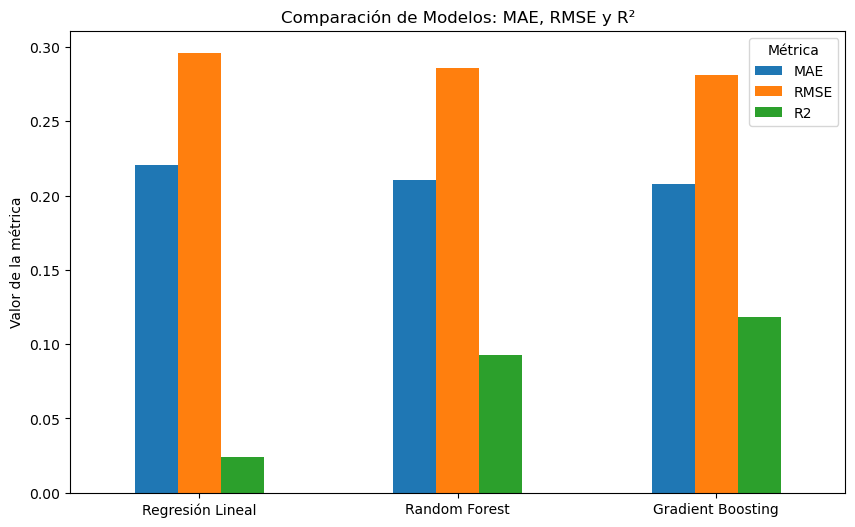

In [26]:
comparacion.T.plot(kind="bar", figsize=(10,6))
plt.title("Comparación de Modelos: MAE, RMSE y R²")
plt.ylabel("Valor de la métrica")
plt.xticks(rotation=0)
plt.legend(title="Métrica")
plt.show()

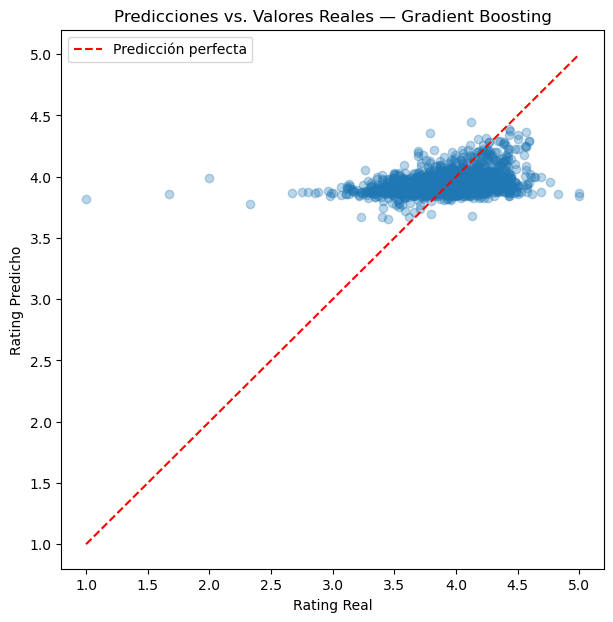

In [27]:
# Visualizacion de como son las predicciones vs el valor real de los libros en el conjunto de prueba

plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred_gb, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", label="Predicción perfecta")
plt.xlabel("Rating Real")
plt.ylabel("Rating Predicho")
plt.title("Predicciones vs. Valores Reales — Gradient Boosting")
plt.legend()
plt.show()

Esta grafica lo que demuestra que o que hace que un libro tenga 2.0 estrellas probablemente no está en los datos (mala escritura, traducción deficiente, expectativas no cumplidas) — son factores cualitativos que ningún dataset podría capturar al 100%

Este comportamiento se llama "regresión hacia la media", y es completamente esperable con un R² bajo: cuando el modelo no tiene suficiente información para diferenciar por qué un libro específico se aleja del promedio, su estrategia más "segura" (la que minimiza el error promedio) es predecir cerca del valor típico casi siempre. Es matemáticamente razonable — pero para casos atípicos (libros muy mal o muy bien calificados), el modelo simplemente no tiene señal suficiente en las variables (num_pages, publisher, language_code, etc.) para saber que ese libro es diferente.

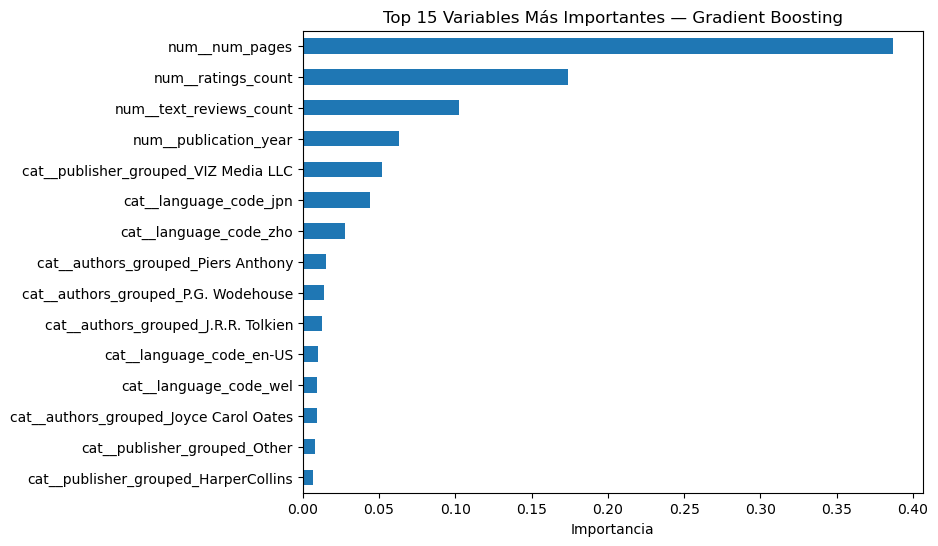

In [28]:
# Importancia de Variables

# Extraer los nombres de las columnas después del One-Hot Encoding
feature_names = modelo_gb.named_steps["prep"].get_feature_names_out()
importancias = modelo_gb.named_steps["model"].feature_importances_

# Armar y ordenar
feat_imp = pd.Series(importancias, index=feature_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
feat_imp.plot(kind="barh")
plt.title("Top 15 Variables Más Importantes — Gradient Boosting")
plt.xlabel("Importancia")
plt.gca().invert_yaxis()
plt.show()

## Conclusiones e Interpretación de Resultados

### Resumen del enfoque

El objetivo de este proyecto fue predecir el rating promedio de un libro (`average_rating`) 
a partir de características de catálogo disponibles al momento de su publicación: número 
de páginas, editorial, idioma, autor, cantidad de calificaciones, cantidad de reseñas y 
año de publicación. Se implementaron y compararon tres modelos de familias distintas: 
Regresión Lineal (modelo base), Random Forest (ensamble por bagging) y Gradient Boosting 
(ensamble por boosting).


**Gradient Boosting fue el modelo con mejor desempeño en las tres métricas evaluadas**, 
lo cual tiene sentido: al construir árboles de forma secuencial, cada uno 
corrigiendo los errores del anterior, logra capturar relaciones no lineales entre las 
variables con mayor precisión que un modelo lineal simple o que árboles construidos de 
forma independiente (Random Forest).

### Sobre el desempeño general (R² bajo)

A pesar de que Gradient Boosting fue el mejor modelo, su R² de 0.118 indica que las 
variables disponibles explican solo una fracción limitada de la variación en los ratings. 
Esto no se interpreta como una falla del modelado, sino como un hallazgo legítimo sobre 
la naturaleza del problema:

- La distribución de `average_rating` está fuertemente concentrada entre 3.5 y 4.5 
  estrellas, lo que reduce el margen de variación disponible para que cualquier modelo 
  explique.
- El rating de un libro depende en gran medida de factores **cualitativos no capturados 
  en este dataset**: calidad de la escritura, traducción, diseño de portada, marketing 
  editorial, momento cultural de publicación, entre otros.
- El gráfico de predicciones vs. valores reales mostró que el modelo tiende a predecir 
  cerca del valor promedio incluso para libros con ratings extremos (muy altos o muy 
  bajos) — un comportamiento esperado (regresión hacia la media) cuando las variables 
  disponibles no logran diferenciar esos casos atípicos.

### Variables más influyentes

Según el análisis de importancia de variables del modelo Gradient Boosting, las 
predictoras más relevantes fueron:
1. `num_pages` — la más influyente, a pesar de no mostrar una relación lineal evidente 
   en el análisis exploratorio, lo que sugiere una relación más compleja que el modelo 
   sí logró capturar.
2. `ratings_count` y `text_reviews_count` — la popularidad/visibilidad del libro aporta 
   señal real sobre su calidad percibida.
3. `publication_year` — sugiere cierto efecto de época en los ratings.

Variables categóricas específicas (idiomas o autores puntuales) tuvieron importancia 
marginal y probablemente reflejan patrones de muestras pequeñas dentro del dataset, más 
que relaciones generalizables — una limitación a tener en cuenta al interpretar esos 
resultados.

### Limitaciones 
- **Variables predominantemente cuantitativas de catálogo**: el dataset no incluye 
  variables de contenido (género literario, sinopsis, calidad de traducción) que 
  probablemente tendrían mayor poder predictivo.
- **Concentración del target**: la baja dispersión de `average_rating` limita 
  estructuralmente el techo de R² alcanzable, independientemente del modelo usado.